In [1]:
from MDToolkit.IO.read_file import pdb_file_to_structured_system, lammps_data_file_to_structured_system, lammps_dump_file_to_simulation
from MDToolkit.IO.write_file import write_lammps_structure_file_atomic_full
from MDToolkit.analysis.diffusivity import compute_MSD

lammps_dump_file = "/media/jrjoseph/Elements/projects/training/water_box_ls6/water_box_nvt_prod_coarse.out"

type_map = {1 : "O", 2 : "H"}

simulation = lammps_dump_file_to_simulation(lammps_dump_file, type_map, "unwrapped")

Processing frames:   0%|          | 0/2001 [00:00<?, ?frame/s]

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_msd(
    msd_data,
    axes=["x", "y", "z", "sum"],
    show_std=True,
    std_label="±1σ",
    ax=None
):

    if ax is None:
        fig, ax = plt.subplots()

    t = msd_data["timesteps"]

    color_map = {
        "x": "C0",
        "y": "C1",
        "z": "C2",
        "sum": "C3"
    }

    label_map = {
        "x": "MSD$_x$",
        "y": "MSD$_y$",
        "z": "MSD$_z$",
        "sum": "Total MSD"
    }

    key_map = {
        "x": ("x_msd", "x_std"),
        "y": ("y_msd", "y_std"),
        "z": ("z_msd", "z_std"),
        "sum": ("sum_msd", "sum_std")
    }

    for axis in axes:

        mean_key, std_key = key_map[axis]
        color = color_map[axis]

        ax.plot(
            t,
            msd_data[mean_key],
            lw=2,
            color=color,
            label=label_map[axis]
        )

        if show_std:
            ax.fill_between(
                t,
                msd_data[mean_key] - msd_data[std_key],
                msd_data[mean_key] + msd_data[std_key],
                color=color,
                alpha=0.2
            )

    ax.set_xlabel("Time Step")
    ax.set_ylabel(r"MSD ($\mathrm{\AA^2}$)")

    handles, labels = ax.get_legend_handles_labels()

    if show_std:
        handles.append(
            Patch(facecolor="gray", alpha=0.2, label=std_label)
        )

    ax.legend(
        handles=handles,
        frameon=False,
        ncol=2,
        loc="best"
    )

    return ax

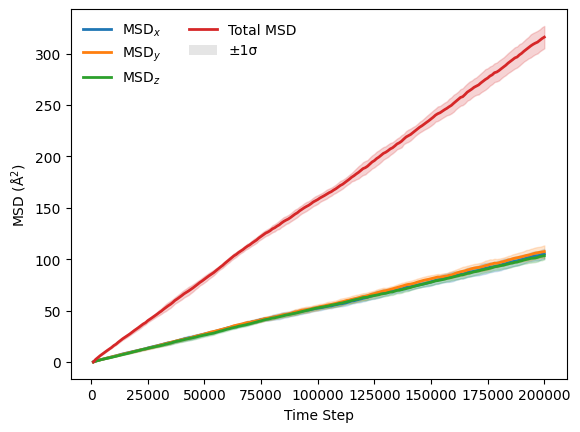

In [3]:
msd_data = compute_MSD(simulation, 10)

plot_msd(msd_data)
plt.show()

In [ ]:
# Diffusivity from MSD
import numpy as np

coefficients, cov_matrix = np.polyfit(msd_data["timesteps"], msd_data["sum_msd"], deg=1, cov=True)

slope = coefficients[0]

# The standard deviation of the coefficients is the square root of the diagonal
slope_std_dev = np.sqrt(cov_matrix[0, 0])

print(f"D (m2/s): {slope * 10**(15) / 10**(20) * 1/6}")
print(f"D std dev: {slope_std_dev * 10**(15) / 10**(20) * 1/6}")

NameError: name 'np' is not defined